# 02. Feature Engineering

Build four features for next-day market stress classification: portfolio volatility, VIX,
yield spread and momentum.

A day is labelled as stress when its realized portfolio volatility exceeds the 75th percentile
of volatility observed before that date. The expanding threshold starts after 252 observations
and is shifted by one day. Features are also lagged by one day, so neither the label boundary nor
the predictors use the held-out future period.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features import build_feature_matrix

## Load prices and build features

In [2]:
prices = pd.read_csv('../data/raw/prices.csv', index_col=0, parse_dates=True)
print(f"Prices shape: {prices.shape}")

features = build_feature_matrix(prices)
print(f"Features shape: {features.shape}")
print(f"\nColumns: {list(features.columns)}")

Prices shape: (2142, 11)
Features shape: (1868, 5)

Columns: ['portfolio_vol', 'vix', 'yield_spread', 'momentum', 'stress']


## Stress regime distribution

In [3]:
stress_counts = features['stress'].value_counts().sort_index()
print("Stress label distribution:")
print(f"  Normal (0): {stress_counts[0]} days ({stress_counts[0]/len(features)*100:.1f}%)")
print(f"  Stress (1): {stress_counts[1]} days ({stress_counts[1]/len(features)*100:.1f}%)")

imbalance_ratio = stress_counts[0] / stress_counts[1]
print(f"\nClass imbalance ratio (normal:stress): {imbalance_ratio:.1f}:1")
print("\nNote: Class imbalance is moderate. Threshold metrics (precision, recall) will be important.")

Stress label distribution:
  Normal (0): 1552 days (83.1%)
  Stress (1): 316 days (16.9%)

Class imbalance ratio (normal:stress): 4.9:1

Note: Class imbalance is moderate. Threshold metrics (precision, recall) will be important.


## Time-series visualization

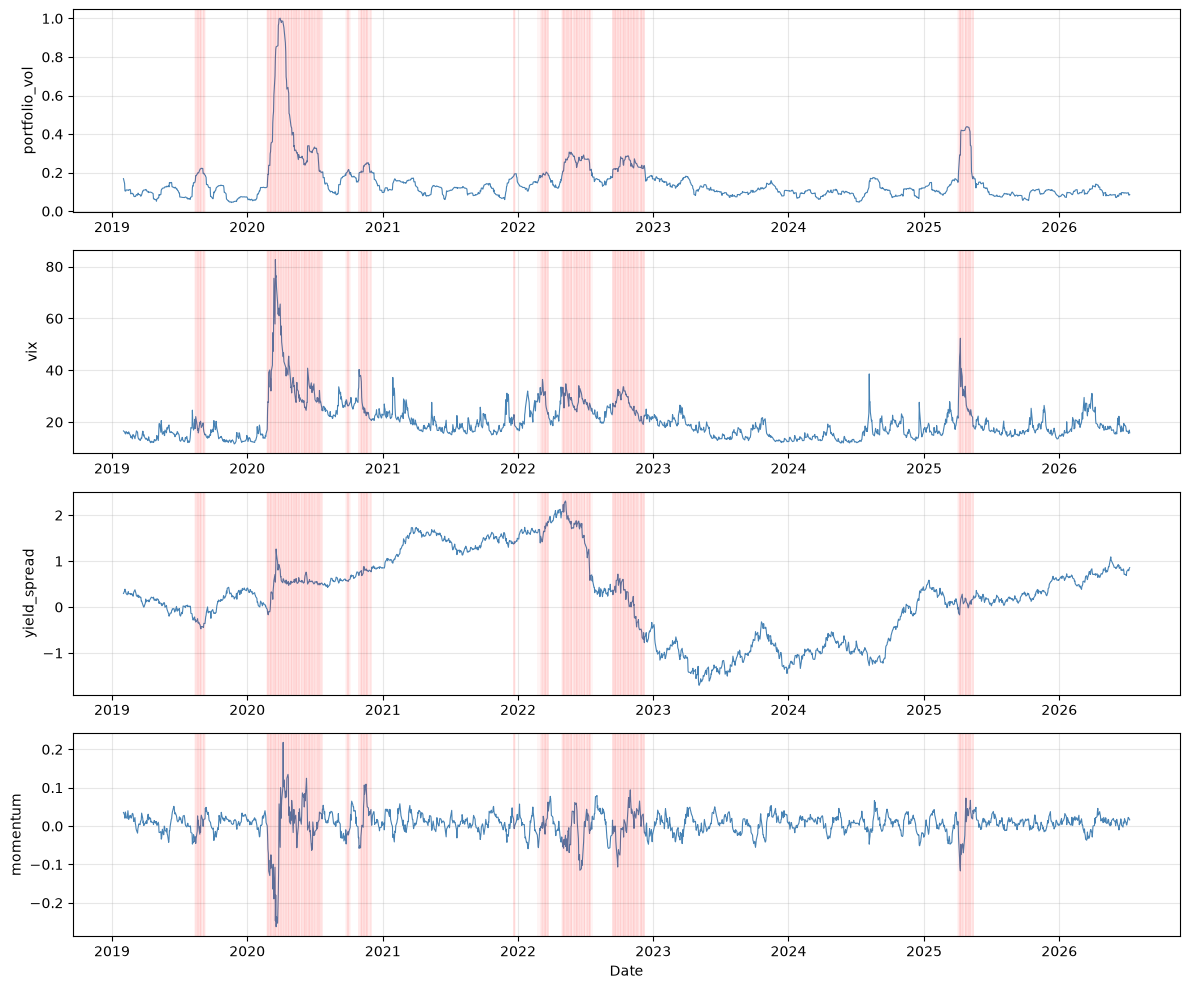

Saved figure: figures/02_feature_timeseries.png


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

for ax, col in zip(axes, ['portfolio_vol', 'vix', 'yield_spread', 'momentum']):
    ax.plot(features.index, features[col], label=col, color='steelblue', linewidth=0.8)

    # Mark individual stress days rather than spanning min-to-max, since
    # stress periods are scattered, not one contiguous block.
    stress_idx = features[features['stress'] == 1].index
    for d in stress_idx:
        ax.axvline(d, alpha=0.04, color='red')

    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.tight_layout()
plt.savefig('../figures/02_feature_timeseries.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/02_feature_timeseries.png")

## Summary statistics

In [5]:
print("Feature summary statistics:")
print(features.describe())

Feature summary statistics:
       portfolio_vol          vix  yield_spread     momentum       stress
count    1868.000000  1868.000000   1868.000000  1868.000000  1868.000000
mean        0.146588    20.143721      0.236842     0.006138     0.169165
std         0.111996     7.475663      0.903513     0.032789     0.374998
min         0.044647    11.540000     -1.704000    -0.262217     0.000000
25%         0.091410    15.370000     -0.445250    -0.006681     0.000000
50%         0.115893    18.139999      0.280000     0.009221     0.000000
75%         0.161354    22.902500      0.789750     0.021904     0.000000
max         1.001025    82.690002      2.308000     0.218165     1.000000


## Save features

In [6]:
features.to_csv('../data/processed/features.csv')
print(f"Saved to data/processed/features.csv ({features.shape[0]} rows × {features.shape[1]} columns)")

Saved to data/processed/features.csv (1868 rows × 5 columns)
